In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from neuralop.losses.differentiation import FiniteDiff

device = torch.device("cuda") # Use GPU 

In [ ]:
## Simulation paparameters
Lx, Ly = 2.0, 2.0 # Domain lengths
nx, ny = 64, 64 # grid resolution
T = 1.0 # Total simulation time
dt = 0.001 # Time step
nu = 0.04 # Viscosity

## Create grid
X = torch.linspace(0, Lx, nx, device=device).repeat(ny, 1).T # numpy meshgrid equivalent
Y = torch.linspace(0, Ly, ny, device=device).repeat(nx, 1)
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)
nt = int(T / dt)

## initializze finite difference opreators
fd = FiniteDiff(dim=2, h=(dx, dy)) # 2차원에서 dx, dy 간격으로 finite difference 계산

## Initial conditions
u = -torch.sin(2 * np.pi * Y).to(device) # Initial velocity field
v = torch.cos(2 * np.pi * X).to(device) # Initial velocity field

In [40]:
u_evolution = [u.clone()]
v_evolution = [v.clone()]

for _ in range(nt):
    # Compute first-order derivatives
    u_x = fd.dx(u)
    u_y = fd.dy(u)
    v_x = fd.dx(v)
    v_y = fd.dy(v)

    # Compute second-order derivatives
    u_xx = fd.dx(u_x)
    u_yy = fd.dy(u_y)
    v_xx = fd.dx(v_x)
    v_yy = fd.dy(v_y)

    # Evolve in time using Euler's method
    u_next = u + dt * (-u * u_x - v * u_y + nu * (u_xx + u_yy))
    v_next = v + dt * (-u * v_x - v * v_y + nu * (v_xx + v_yy))

    u, v = u_next.clone(), v_next.clone()
    u_evolution.append(u.clone())
    v_evolution.append(v.clone())



u_evolution = torch.stack(u_evolution).cpu().numpy() # (time, )
v_evolution = torch.stack(v_evolution).cpu().numpy()




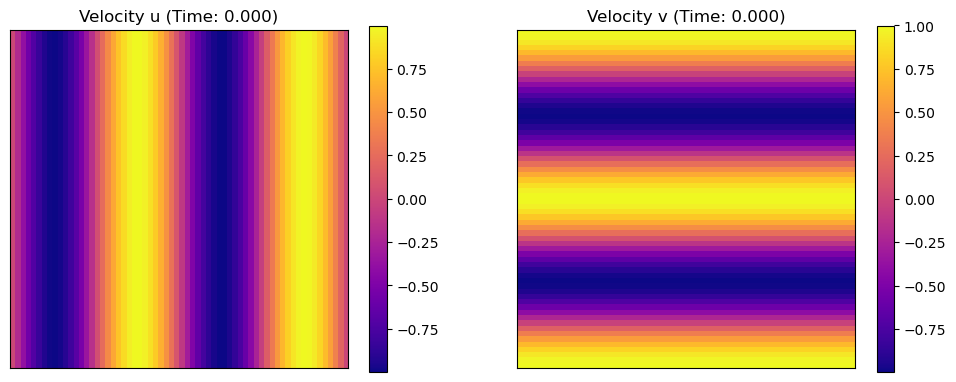

In [43]:
num_frames = 100
frame_indices = (
    torch.linspace(0, len(u_evolution) - 1, num_frames, dtype=torch.int).cpu().numpy()
)
u_frames = u_evolution[frame_indices]
v_frames = v_evolution[frame_indices]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
cmap_u = axs[0].imshow(u_frames[0], extent=[0, Lx, 0, Ly], origin="lower", cmap="plasma")
axs[0].set_title("Velocity u")
plt.colorbar(cmap_u, ax=axs[0], shrink=0.75)
cmap_v = axs[1].imshow(v_frames[0], extent=[0, Lx, 0, Ly], origin="lower", cmap="plasma")
axs[1].set_title("Velocity v")
plt.colorbar(cmap_v, ax=axs[1], shrink=0.75)


def update(frame):
    cmap_u.set_data(u_frames[frame])
    cmap_v.set_data(v_frames[frame])
    axs[0].set_title(f"Velocity u (Time: {frame_indices[frame] * dt:.3f})")
    axs[1].set_title(f"Velocity v (Time: {frame_indices[frame] * dt:.3f})")
    axs[0].set_xticks([])
    axs[0].set_yticks([])
    axs[1].set_xticks([])
    axs[1].set_yticks([])
    return cmap_u, cmap_v

ani = animation.FuncAnimation(fig, update, frames=len(u_frames), interval=50, blit=False)

